<a href="https://colab.research.google.com/github/hyeriong/Data_Analysis/blob/main/Designing_Interfaces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 정보 과잉 시대의 뉴스 독해: 능동적 이해를 위한 인터페이스 설계

- 연구 목적: 본 연구는 뉴스 기사에 대한 질의응답(QA) 데이터를 분석하여, 정보 과잉 시대에서의 수동적 정보 습득에서 벗어나 능동적이고 직접적인 뉴스 정보 이해를 위한 인터페이스를 설계하고자 한다.


## 데이터 수집
- QA 데이터 수집 :AI-Hub 뉴스 기사 기계독해 데이터
https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=data&dataSetSn=577

## 데이터 생성 및 선별
- 질문-답변 쌍 만들기: 뉴스 본문을 읽고 독자가 이해해야 할 포인트로 질문을 만들고, 답변을 정확히 적는다.

## 맞춤형 데이터셋 구축 방법
- 주제별 분류: QA를 주제별(사회, 경제, 문화 등)로 분류
- 난이도 태깅 : QA 쌍마다 난이도 표시

## 추가로 고려?
- 자동화 도구 개발: 질문 생성, 난이도 분류 등을 반자동화하는 Python 스크립트 만들기.

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # GPU 사용 안 함

import torch
from sentence_transformers import SentenceTransformer

In [ ]:
# 필수 라이브러리
import pandas as pd
import json
import os

In [ ]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 파일 경로 설정
data_folder = '/content/drive/MyDrive/원천데이터'

file_paths = [
    os.path.join(data_folder, 'TS_span_extraction.json'),
    os.path.join(data_folder, 'TS_span_inference.json'),
    os.path.join(data_folder, 'TS_text_entailment.json'),
    os.path.join(data_folder, 'TS_unanswerable.json')
]

In [ ]:
# 불완전한 json 파일이 있으므로 json 파일의 시작과 끝 보완하기
# JSON 파일 자동 복구
input_path = file_paths[0]
output_path = '/content/drive/MyDrive/원천데이터/fixed_json.json'

# JSON 복구
with open(input_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

# 시작과 끝 확인 및 보완
if not lines[0].strip().startswith('{'):
    lines.insert(0, '{\n')

if not lines[-1].strip().endswith('}'):
    lines.append('\n}')

# 복구된 JSON 파일 저장
with open(output_path, 'w', encoding='utf-8') as file:
    file.writelines(lines)

print(f"JSON 파일이 수정되어 저장되었습니다: {output_path}")

JSON 파일이 수정되어 저장되었습니다: /content/drive/MyDrive/원천데이터/fixed_json.json


In [ ]:
# JSON 유효성 검사
try:
    with open(output_path, 'r', encoding='utf-8') as file:
        json_data = json.load(file)
    print("JSON 파일이 올바른 형식입니다.")
except json.JSONDecodeError as e:
    print(f"JSONDecodeError: {e}")

JSON 파일이 올바른 형식입니다.


In [ ]:
# JSON 라인 단위 읽기
data_list = []
with open(output_path, 'r', encoding='utf-8') as file:
    try:
        json_data = json.load(file)  # 전체 로드
        for entry in json_data.get('data', []):
            title = entry.get('doc_title', '')
            paragraphs = entry.get('paragraphs', [])
            for paragraph in paragraphs:
                context = paragraph.get('context', '')
                data_list.append({
                    'title': title,
                    'content': context
                })
    except json.JSONDecodeError as e:
        print(f"JSONDecodeError: {e}")

# DataFrame으로 변환
import pandas as pd
df = pd.DataFrame(data_list)
print(df.head())

                                   title  \
0                익산 서부권역 다목적 체육관, 다음달 개관   
1  무주군건강가정·다문화가족지원센터, '아빠하고 나하고' 프로그램 운영   
2                          양희은의 '뜻밖의 만남'   
3                전북 산업단지 대개조 지역경제 도약 기회로   
4        익산 함라면 야산서 불… 신원 미상 남성 시신 1구 발견   

                                             content  
0  익산시 서부권역 다목적 체육관이 내달 개관을 앞두고 막바지 개관 준비가 한창이다. ...  
1  무주군건강가정ㆍ다문화가족지원센터(센터장 장진원)가 아버지와 자녀를 대상으로 ‘아빠하...  
2  양희은의 노래 <엄마가 딸에게>는 엄마와 딸이 차마 말하지 못하는 속마음을 서로에게...  
3  군산ㆍ익산ㆍ완주지역의 노후 산업단지에 내년부터 3년간 국비와 지방비, 민간자본 등 ...  
4  25일 오전 11시 35분께 익산시 함라면의 한 야산에서 불이 나 1시간 30분만에...  


In [ ]:
# 현재 df: title, content 컬럼 있음

qa_list = []

for idx, row in df.iterrows():
    title = row['title']
    content = row['content']

    # 질문 생성
    # 방법 1: 제목 기반으로 간단한 질문 만들기
    question = f"{title}에 대해 알려주세요."

    # 답변 생성
    # 방법 1: content에서 첫 번째 문장을 답변으로
    first_sentence = content.split('.')[0]  # . 기준 첫 번째 문장
    first_sentence = first_sentence.strip()

    if not first_sentence:
        answer = content[:100]  # 문장이 없으면 앞 100자만 자르기
    else:
        answer = first_sentence

    qa_list.append({
        'title': title,
        'context': content,
        'question': question,
        'answer': answer
    })

# 최종 QA DataFrame
qa_df = pd.DataFrame(qa_list)

# 결과 출력
print(qa_df.head())

# 필요한 경우 CSV 저장
qa_df.to_csv('/content/drive/MyDrive/원천데이터/final_qa_dataset.csv', index=False, encoding='utf-8-sig')
print("QA 데이터셋 저장 완료!")


                                   title  \
0                익산 서부권역 다목적 체육관, 다음달 개관   
1  무주군건강가정·다문화가족지원센터, '아빠하고 나하고' 프로그램 운영   
2                          양희은의 '뜻밖의 만남'   
3                전북 산업단지 대개조 지역경제 도약 기회로   
4        익산 함라면 야산서 불… 신원 미상 남성 시신 1구 발견   

                                             context  \
0  익산시 서부권역 다목적 체육관이 내달 개관을 앞두고 막바지 개관 준비가 한창이다. ...   
1  무주군건강가정ㆍ다문화가족지원센터(센터장 장진원)가 아버지와 자녀를 대상으로 ‘아빠하...   
2  양희은의 노래 <엄마가 딸에게>는 엄마와 딸이 차마 말하지 못하는 속마음을 서로에게...   
3  군산ㆍ익산ㆍ완주지역의 노후 산업단지에 내년부터 3년간 국비와 지방비, 민간자본 등 ...   
4  25일 오전 11시 35분께 익산시 함라면의 한 야산에서 불이 나 1시간 30분만에...   

                                           question  \
0                익산 서부권역 다목적 체육관, 다음달 개관에 대해 알려주세요.   
1  무주군건강가정·다문화가족지원센터, '아빠하고 나하고' 프로그램 운영에 대해 알려주세요.   
2                          양희은의 '뜻밖의 만남'에 대해 알려주세요.   
3                전북 산업단지 대개조 지역경제 도약 기회로에 대해 알려주세요.   
4        익산 함라면 야산서 불… 신원 미상 남성 시신 1구 발견에 대해 알려주세요.   

                                              answer  
0       익산시 

In [ ]:
# 필수 라이브러리
import pandas as pd
import json
import os

# 1. 데이터 로드 (기존에 만든 df 사용)
# 여기서는 'df'에 title, content 컬럼이 있다고 가정

# 2. 토픽 키워드 체계화
topic_keywords = {
    '정치': ['정부', '정책', '국회', '대통령', '선거', '외교', '정당', '국방'],
    '경제': ['경제', '산업', '금융', '부동산', '무역', '일자리', '수출', '자본', '기업', '증시', '소비'],
    '사회': ['사건', '사고', '복지', '환경', '재난', '보건', '교육', '학생', '학교', '노인', '청소년', '소방', '체육관', '센터', '지역'],
    '문화': ['공연', '전시', '영화', '음악', '문학', '스포츠', '예술', '축제', '연예인', '방송', '드라마', '전통'],
    'IT/과학': ['기술', '인터넷', 'AI', '과학', '로봇', '우주', '데이터', '반도체', '스마트폰', '앱', '클라우드'],
    '세계': ['세계', '해외', '국제', '미국', '중국', '일본', '유럽', '전쟁', '분쟁', '외신', '대사관'],
}

# 3. 난이도 태깅 함수
def estimate_difficulty(text):
    word_count = len(text.split())
    if word_count <= 20:
        return '쉬움'
    elif word_count <= 40:
        return '보통'
    else:
        return '어려움'

# 4. 주제 분류 함수
def assign_topic(title, content):
    combined_text = (title + " " + content).lower()  # 소문자 변환
    for topic, keywords in topic_keywords.items():
        for keyword in keywords:
            if keyword.lower() in combined_text:
                return topic
    return '기타'

# 5. 질문-답변 생성 및 주제/난이도 태깅
qa_list = []

for idx, row in df.iterrows():
    title = row['title']
    content = row['content']

    # 질문 생성
    question = f"{title}에 대해 알려주세요."

    # 답변 생성
    first_sentence = content.split('.')[0].strip()
    if not first_sentence:
        answer = content[:100]
    else:
        answer = first_sentence

    # 주제 분류
    topic = assign_topic(title, content)

    # 난이도 추정
    difficulty = estimate_difficulty(answer)

    qa_list.append({
        'title': title,
        'context': content,
        'question': question,
        'answer': answer,
        'topic': topic,
        'difficulty': difficulty
    })

# 6. 최종 DataFrame
qa_df = pd.DataFrame(qa_list)

# 7. 분류 결과 요약 출력
print("주제별 분포:")
print(qa_df['topic'].value_counts())
print("\n난이도별 분포:")
print(qa_df['difficulty'].value_counts())

# 8. 예시 출력
print("\nQA 예시:")
print(qa_df[['title', 'question', 'answer', 'topic', 'difficulty']].head())

# 9. 저장
save_path = '/content/drive/MyDrive/원천데이터/final_qa_dataset_with_topic_and_difficulty.csv'
qa_df.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"\n최종 데이터셋 저장 완료: {save_path}")


주제별 분포:
topic
사회       37713
정치       32452
경제       22267
문화        9768
기타        6643
세계        1981
IT/과학     1186
Name: count, dtype: int64

난이도별 분포:
difficulty
쉬움     99430
보통     12437
어려움      143
Name: count, dtype: int64

QA 예시:
                                   title  \
0                익산 서부권역 다목적 체육관, 다음달 개관   
1  무주군건강가정·다문화가족지원센터, '아빠하고 나하고' 프로그램 운영   
2                          양희은의 '뜻밖의 만남'   
3                전북 산업단지 대개조 지역경제 도약 기회로   
4        익산 함라면 야산서 불… 신원 미상 남성 시신 1구 발견   

                                           question  \
0                익산 서부권역 다목적 체육관, 다음달 개관에 대해 알려주세요.   
1  무주군건강가정·다문화가족지원센터, '아빠하고 나하고' 프로그램 운영에 대해 알려주세요.   
2                          양희은의 '뜻밖의 만남'에 대해 알려주세요.   
3                전북 산업단지 대개조 지역경제 도약 기회로에 대해 알려주세요.   
4        익산 함라면 야산서 불… 신원 미상 남성 시신 1구 발견에 대해 알려주세요.   

                                              answer topic difficulty  
0       익산시 서부권역 다목적 체육관이 내달 개관을 앞두고 막바지 개관 준비가 한창이다    사회         쉬움  
1  무주군건강가정ㆍ다문화가족지원센터(

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 34 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.7 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126101 files and direc

<ipython-input-11-9274ddf45d8a>:17: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-11-9274ddf45d8a>:17: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-11-9274ddf45d8a>:17: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-11-9274ddf45d8a>:17: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-11-9274ddf45d8a>:17: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-11-9274ddf45d8a>:17: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-11-9274ddf45d8a>:17: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipy

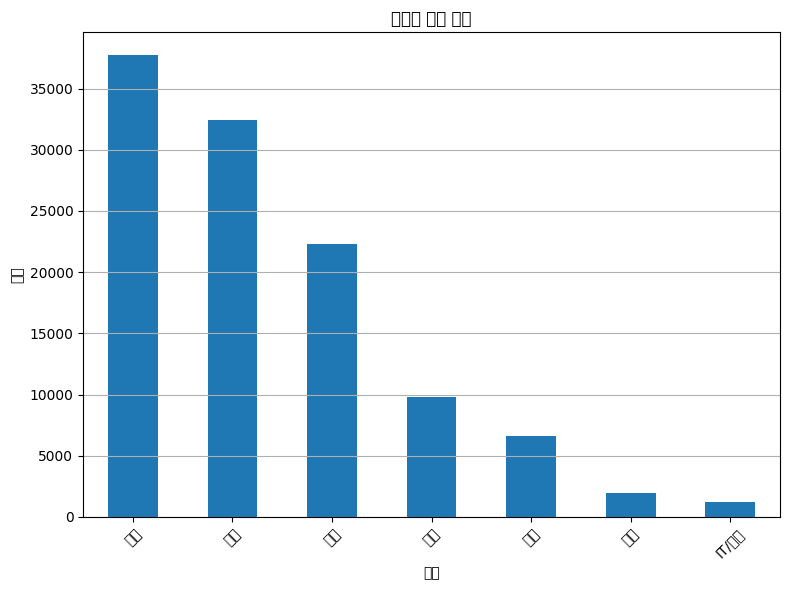

In [ ]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Colab에서는 필요할 수도 있음)
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'  # 한글 깨짐 방지

# 주제별 분포 시각화
topic_counts = qa_df['topic'].value_counts()

plt.figure(figsize=(8, 6))
topic_counts.plot(kind='bar')
plt.title('주제별 뉴스 분포')
plt.xlabel('주제')
plt.ylabel('개수')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

<ipython-input-12-232ba6c563f6>:9: UserWarning: Glyph 45212 (\N{HANGUL SYLLABLE NAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-232ba6c563f6>:9: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-232ba6c563f6>:9: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-232ba6c563f6>:9: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-232ba6c563f6>:9: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-232ba6c563f6>:9: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-232ba6c563f6>:9: UserWarning: Glyph 49772 (\N{HANGUL SYLLABLE SWI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-

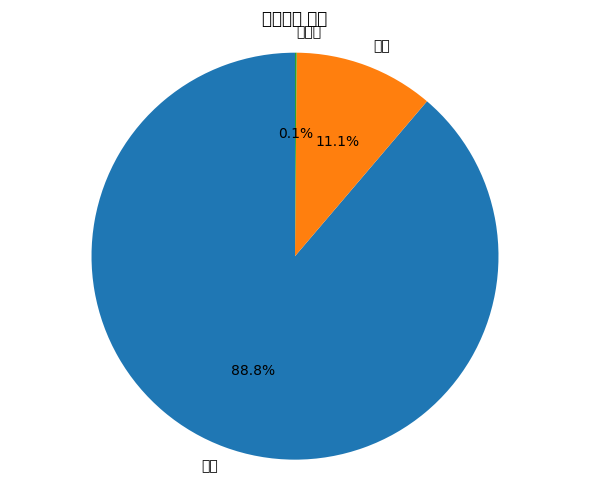

In [ ]:
# 난이도별 분포 시각화
difficulty_counts = qa_df['difficulty'].value_counts()

plt.figure(figsize=(6, 5))
difficulty_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('난이도별 분포')
plt.ylabel('')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. 질문(question) 벡터화 준비
vectorizer = TfidfVectorizer()
vectorizer.fit(qa_df['question'])  # 기존 질문들을 학습

question_vectors = vectorizer.transform(qa_df['question'])

# 2. 사용자 질문 입력받고, 가장 비슷한 질문 찾기
def answer_question(user_question):
    user_vector = vectorizer.transform([user_question])

    # 기존 질문들과 코사인 유사도 계산
    similarities = cosine_similarity(user_vector, question_vectors)

    # 가장 유사도가 높은 인덱스 찾기
    top_idx = similarities.argmax()

    # 해당하는 답변 출력
    matched_question = qa_df.iloc[top_idx]['question']
    matched_answer = qa_df.iloc[top_idx]['answer']
    matched_topic = qa_df.iloc[top_idx]['topic']

    print(f"\n[당신의 질문] {user_question}")
    print(f"[매칭된 질문] {matched_question}")
    print(f"[답변] {matched_answer}")
    print(f"[주제] {matched_topic}")

# 테스트
user_question = input("질문을 입력하세요: ")
answer_question(user_question)

질문을 입력하세요: 내 눈 바로알기 프로젝트 업무 협약은 한국자유총연맹 공주시지회 주관인가?

[당신의 질문] 내 눈 바로알기 프로젝트 업무 협약은 한국자유총연맹 공주시지회 주관인가?
[매칭된 질문] 한국자유총연맹 공주시지회와 공주시성모안과 '내 눈 바로알기 프로젝트'업무 협약에 대해 알려주세요.
[답변] 한국자유총연맹 충남 공주시지회가 공주시성모안과와 '내 눈 바로알기 프로젝트'업무협약을 맺고 의료서비스 지원에 나서기로 했다고 9일 밝혔다
[주제] 사회


### 장점
- 질문을 했을 때, 기사로부터 추출된 '매칭된 질문'을 연결하여 답변해줌.

### 단점
- 매칭되는 질문이 부자연스러움.

In [ ]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 34.2 MB/s eta 0:00:00


In [ ]:
!pip install transformers
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

# 모델 로드 (빠른 모델 사용: paraphrase-multilingual-MiniLM-L12-v2)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 뉴스 200개만 샘플링 (random_state는 결과 고정을 위해 설정)
qa_sample = qa_df.sample(n=200, random_state=42).copy()

# 본문 리스트 추출
contexts = qa_sample['context'].tolist()

# BERT 임베딩
print("뉴스 샘플 임베딩 시작...")
context_embeddings = model.encode(contexts, batch_size=32, show_progress_bar=True, convert_to_tensor=True)
print("✅ 뉴스 샘플 임베딩 완료!")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

뉴스 샘플 임베딩 시작...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

✅ 뉴스 샘플 임베딩 완료!


In [ ]:
qa_sample

,title,context,question,answer,topic,difficulty
0,완주군의회 일자리 간담회,코로나19로 어려움에 처해있는 소상공인 및 지역 유관단체와 릴레이 간담회를 진행하고...,완주군의회 일자리 간담회에 대해 알려주세요.,코로나19로 어려움에 처해있는 소상공인 및 지역 유관단체와 릴레이 간담회를 진행하고...,경제,보통
1,"야 부산시장 후보군 ""조속한 사면"" 촉구…여권 의도에는 온도차",국민의힘 부산시장 보궐선거 후보들은 이명박·박근혜 두 전직 대통령의 사면 논란에 대...,"야 부산시장 후보군 ""조속한 사면"" 촉구…여권 의도에는 온도차에 대해 알려주세요.",국민의힘 부산시장 보궐선거 후보들은 이명박·박근혜 두 전직 대통령의 사면 논란에 대...,정치,쉬움
2,"금산군, 맘 CEO 진로비전 아카데미 마무리",충남 금산군은 지난 3∼25일까지 매주 목요일 진행한 자녀와 함께하는 맘 CEO 진...,"금산군, 맘 CEO 진로비전 아카데미 마무리에 대해 알려주세요.",충남 금산군은 지난 3∼25일까지 매주 목요일 진행한 자녀와 함께하는 맘 CEO 진...,사회,쉬움
3,"청양소방서, 6월부터 위험물 운반자 안전교육 필수",청양소방서(서장 김경호)는 위험물안전관리법에 따라 위험물과 운반자의 자격요건을 강화...,"청양소방서, 6월부터 위험물 운반자 안전교육 필수에 대해 알려주세요.",청양소방서(서장 김경호)는 위험물안전관리법에 따라 위험물과 운반자의 자격요건을 강화...,사회,쉬움
4,"장흥군, 원목표고 종균 접종 본격 시작",장흥군은 봄철 본격적인 원목표고 종균 접종 시기를 맞아 장흥표고의 명성을 지키기 위...,"장흥군, 원목표고 종균 접종 본격 시작에 대해 알려주세요.",장흥군은 봄철 본격적인 원목표고 종균 접종 시기를 맞아 장흥표고의 명성을 지키기 위...,기타,쉬움
...,...,...,...,...,...,...
195,김제 성산전망대 통신기지국 철거된다,오랫동안 도심 공원 미관과 어울리지 않아 지속적인 철거를 지적받아온 김제시 성산공원...,김제 성산전망대 통신기지국 철거된다에 대해 알려주세요.,오랫동안 도심 공원 미관과 어울리지 않아 지속적인 철거를 지적받아온 김제시 성산공원...,기타,쉬움
196,한국자유총연맹 공주시지회와 공주시성모안과 '내 눈 바로알기 프로젝트'업무 협약,한국자유총연맹 충남 공주시지회가 공주시성모안과와 '내 눈 바로알기 프로젝트'업무협약...,한국자유총연맹 공주시지회와 공주시성모안과 '내 눈 바로알기 프로젝트'업무 협약에 대...,한국자유총연맹 충남 공주시지회가 공주시성모안과와 '내 눈 바로알기 프로젝트'업무협약...,사회,쉬움
197,노르웨이·독일에 네덜란드 대표팀까지 “‘월드컵 개최’ 카타르 인권탄압 규탄”,내년 카타르월드컵에 앞서 지역예선을 치르고 있는 유럽 국가대표팀 선수들이 개최국 카...,노르웨이·독일에 네덜란드 대표팀까지 “‘월드컵 개최’ 카타르 인권탄압 규탄”에 대해...,내년 카타르월드컵에 앞서 지역예선을 치르고 있는 유럽 국가대표팀 선수들이 개최국 카...,정치,쉬움
198,"화이자 백신 유통 쉬워진다… 美FDA, '일반 냉동고' 보관 허용",미국 화이자와 독일 바이오엔테크가 공동 개발한 신종 코로나바이러스 감염증(코로나19...,"화이자 백신 유통 쉬워진다… 美FDA, '일반 냉동고' 보관 허용에 대해 알려주세요.",미국 화이자와 독일 바이오엔테크가 공동 개발한 신종 코로나바이러스 감염증(코로나19...,사회,쉬움


In [ ]:
def fast_keyword_filter_system_sample(user_question, top_k=3):
    # 1. 사용자 질문 전처리
    user_words = set(user_question.lower().split())

    # 2. word_set 컬럼이 없을 경우에만 생성 (질문 기준)
    if 'word_set' not in qa_sample.columns:
        qa_sample['word_set'] = qa_sample['question'].apply(lambda x: set(x.lower().split()))

    # 3. 키워드 매칭 비율 계산
    match_ratios = qa_sample['word_set'].apply(
        lambda ws: len(user_words & ws) / len(user_words) if user_words else 0
    )

    # 4. 30% 이상 겹치는 항목만 필터링
    filtered_indices = match_ratios[match_ratios > 0.3].index.tolist()

    if not filtered_indices:
        print("관련 뉴스가 없습니다.")
        return

    # 5. 필터링된 뉴스에 대해 임베딩 검색
    filtered_embeddings = context_embeddings[[qa_sample.index.get_loc(i) for i in filtered_indices]]
    question_embedding = model.encode(user_question, convert_to_tensor=True)
    cos_scores = util.cos_sim(question_embedding, filtered_embeddings)[0]

    # 6. 상위 top_k 결과 출력
    topk_local_indices = torch.topk(cos_scores, k=min(top_k, len(filtered_indices))).indices.tolist()

    for rank, local_idx in enumerate(topk_local_indices, 1):
        global_idx = filtered_indices[local_idx]
        row = qa_sample.loc[global_idx]

        print(f"\n[{rank}] 제목: {row['title']}")
        print(f"유사도: {cos_scores[local_idx].item():.4f}")
        print(f"주제: {row['topic']}")
        print(f"답변: {row['answer']}")
        print(f"(본문 일부) {row['context'][:150]}...")


In [ ]:
user_question = input("질문을 입력하세요: ")
fast_keyword_filter_system_sample(user_question, top_k=3)

질문을 입력하세요: 내 눈 바로알기 프로젝트 업무 협약은 한국자유총연맹 공주시지회 주관인가?

[1] 제목: 한국자유총연맹 공주시지회와 공주시성모안과 '내 눈 바로알기 프로젝트'업무 협약
유사도: 0.4910
주제: 사회
답변: 한국자유총연맹 충남 공주시지회가 공주시성모안과와 '내 눈 바로알기 프로젝트'업무협약을 맺고 의료서비스 지원에 나서기로 했다고 9일 밝혔다
(본문 일부) 한국자유총연맹 충남 공주시지회가 공주시성모안과와 '내 눈 바로알기 프로젝트'업무협약을 맺고 의료서비스 지원에 나서기로 했다고 9일 밝혔다. 

더욱이 협약과 함께 어려운 어르신을 위한 무료 백내장 수술을 8일과 9일 이틀에 걸쳐 양쪽눈 수술을 진행 훈훈함을 더해주고 있...


In [ ]:
from tqdm import tqdm

# 1. 모델 로드
model = SentenceTransformer('snunlp/KR-SBERT-V40K-klueNLI-augSTS')

# 2. 뉴스 200개 샘플 추출 (이미 했다면 생략 가능)
qa_sample = qa_df.sample(n=200, random_state=42).copy()

# 3. 임베딩
print("▶ KR-SBERT로 뉴스 임베딩 중...")
contexts = qa_sample['context'].tolist()
context_embeddings = model.encode(contexts, batch_size=32, show_progress_bar=True, convert_to_tensor=True)
print("✅ 완료!")

# 4. 저장
torch.save(context_embeddings, 'krbert_sample_embeddings.pt')
qa_sample.to_csv('qa_sample_with_context.csv', index=False)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.02k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

▶ KR-SBERT로 뉴스 임베딩 중...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

✅ 완료!


In [ ]:
from sentence_transformers import util

# 저장된 임베딩과 데이터 로드
context_embeddings = torch.load('krbert_sample_embeddings.pt')
qa_sample = pd.read_csv('qa_sample_with_context.csv')

def krbert_topk_recommend(user_question, top_k=3):
    # 질문 임베딩
    question_embedding = model.encode(user_question, convert_to_tensor=True)

    # 코사인 유사도 계산
    cos_scores = util.cos_sim(question_embedding, context_embeddings)[0]
    topk_indices = torch.topk(cos_scores, k=top_k).indices

    # 결과 출력
    for rank, idx in enumerate(topk_indices, 1):
        idx = idx.item()
        title = qa_sample.iloc[idx]['title']
        answer = qa_sample.iloc[idx]['answer']
        context = qa_sample.iloc[idx]['context']
        topic = qa_sample.iloc[idx]['topic']
        score = cos_scores[idx].item()

        print(f"\n[{rank}] 제목: {title}")
        print(f"유사도: {score:.4f}")
        print(f"주제: {topic}")
        print(f"답변: {answer}")
        print(f"(본문 일부) {context[:150]}...")

In [ ]:
user_question = input("질문을 입력하세요: ")
krbert_topk_recommend(user_question, top_k=3)

질문을 입력하세요: 한국자유총연맹 공주시지회가 업무 협약을 통해 내 눈 바로알기 프로젝트를 진행해?

[1] 제목: 한국자유총연맹 공주시지회와 공주시성모안과 '내 눈 바로알기 프로젝트'업무 협약
유사도: 0.5038
주제: 사회
답변: 한국자유총연맹 충남 공주시지회가 공주시성모안과와 '내 눈 바로알기 프로젝트'업무협약을 맺고 의료서비스 지원에 나서기로 했다고 9일 밝혔다
(본문 일부) 한국자유총연맹 충남 공주시지회가 공주시성모안과와 '내 눈 바로알기 프로젝트'업무협약을 맺고 의료서비스 지원에 나서기로 했다고 9일 밝혔다. 

더욱이 협약과 함께 어려운 어르신을 위한 무료 백내장 수술을 8일과 9일 이틀에 걸쳐 양쪽눈 수술을 진행 훈훈함을 더해주고 있...

[2] 제목: 남원시, 지자체 합동평가 4년 연속 최우수 기관 선정
유사도: 0.4194
주제: 정치
답변: 남원시가 행정안전부에서 실시하는 ‘2020년 지방자치단체 합동평가’ 결과, 최우수 기관에 선정됐다고 29일 밝혔다
(본문 일부) 남원시가 행정안전부에서 실시하는 ‘2020년 지방자치단체 합동평가’ 결과, 최우수 기관에 선정됐다고 29일 밝혔다. 

이로써 시는 2018년부터 4년 연속 최우수 기관으로 선정됐으며 전라북도 1위로 도내 최고 수준의 종합 행정력과 고품격 서비스가 제공되고 있음을 인정...

[3] 제목: 공주시, '꽃도 선물하고 지역화훼 농가도 돕고'
유사도: 0.4055
주제: 사회
답변: 충남 공주시가 코로나19로 어려운 지역 화훼농가를 돕고 생명존중 분위기를 확산시키기 위해 꽃 화분 전달사업을 실시했다고 8일 밝혔다
(본문 일부) 충남 공주시가 코로나19로 어려운 지역 화훼농가를 돕고 생명존중 분위기를 확산시키기 위해 꽃 화분 전달사업을 실시했다고 8일 밝혔다. 

이를 위해 시는 보건소에 등록, 집중 관리되고 있는 독거노인 등 1:1 맞춤형 멘토링 사업대상자 100여명을 대상으로 지역 화훼농장...
